# 03 — Exploratory Data Analysis

Exploratory analysis on the cleaned and merged dataset.
Each plot answers one question — write your interpretation in the markdown cell below each plot.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
df.describe()

Loaded 5381 rows, 20 columns


,id,budget,revenue,runtime,release_year,vote_average,vote_count,popularity,tmdb_popularity,imdb_rating,imdb_votes,tomatometer_rating,audience_rating,roi
count,5381.000000,5.381000e+03,5.381000e+03,5380.000000,5381.000000,5381.000000,5381.000000,5381.000000,3328.000000,5379.000000,5.379000e+03,4376.000000,4375.000000,5.381000e+03
mean,60664.565508,3.109480e+07,9.031812e+07,109.827695,1999.757666,6.272849,732.309422,9.774289,29.217015,6.506525,1.433255e+05,57.156993,62.307429,5.564899e+05
std,95613.916930,4.016263e+07,1.661423e+08,22.041188,15.919325,0.927983,1251.520813,13.818399,35.963375,1.004368,2.429276e+05,28.216296,19.736093,2.168566e+07
min,5.000000,1.000000e+00,1.000000e+00,0.000000,1915.000000,0.000000,0.000000,0.000001,0.019984,1.200000,1.030000e+02,0.000000,9.000000,-9.999995e+01
25%,8818.000000,5.037000e+06,7.011317e+06,95.000000,1994.000000,5.700000,77.000000,5.443097,10.515966,5.900000,1.898750e+04,33.000000,47.000000,-2.129557e+01
50%,14396.000000,1.700000e+07,2.991874e+07,106.000000,2004.000000,6.300000,276.000000,8.388773,20.666297,6.600000,6.089900e+04,61.000000,64.000000,1.056683e+02
75%,59981.000000,4.000000e+07,9.996575e+07,120.000000,2011.000000,6.900000,798.000000,11.720358,37.635654,7.200000,1.596115e+05,83.000000,79.000000,3.244444e+02
max,443319.000000,3.800000e+08,2.787965e+09,338.000000,2017.000000,9.100000,14075.000000,547.488298,875.581305,9.300000,3.183071e+06,100.000000,98.000000,1.239638e+09


## 1. Budget Distribution

Budget values span a very wide range — the plot is unreadable without log scale.

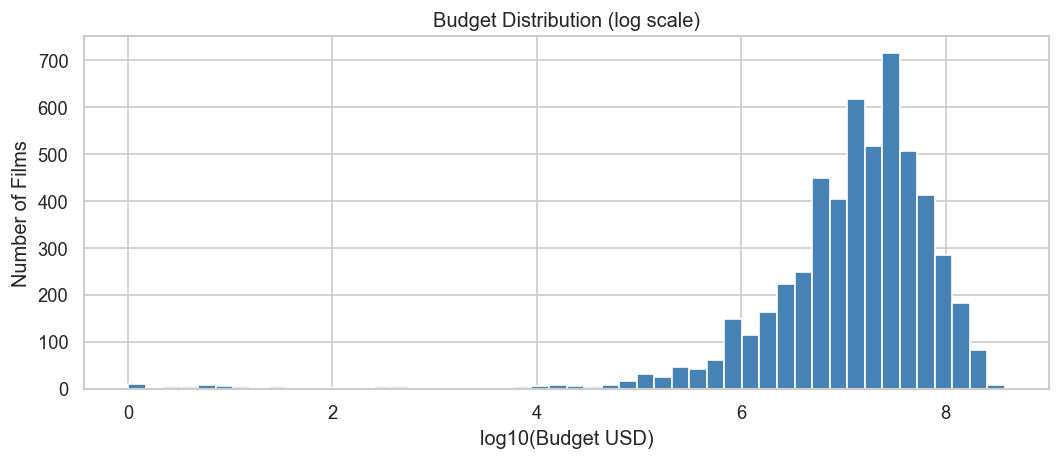

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(df['budget']), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('log10(Budget USD)')
ax.set_ylabel('Number of Films')
ax.set_title('Budget Distribution (log scale)')
plt.tight_layout()
plt.show()

**Interpretation:** Budget distribution is right-skewed even on log scale. The majority of films cluster between $1M–$50M (log10 ≈ 6–7.7). Films exceeding $100M (log10 > 8) are few but their presence distorts linear-scale analysis — which is why log scale is essential throughout.

## 2. Revenue Distribution

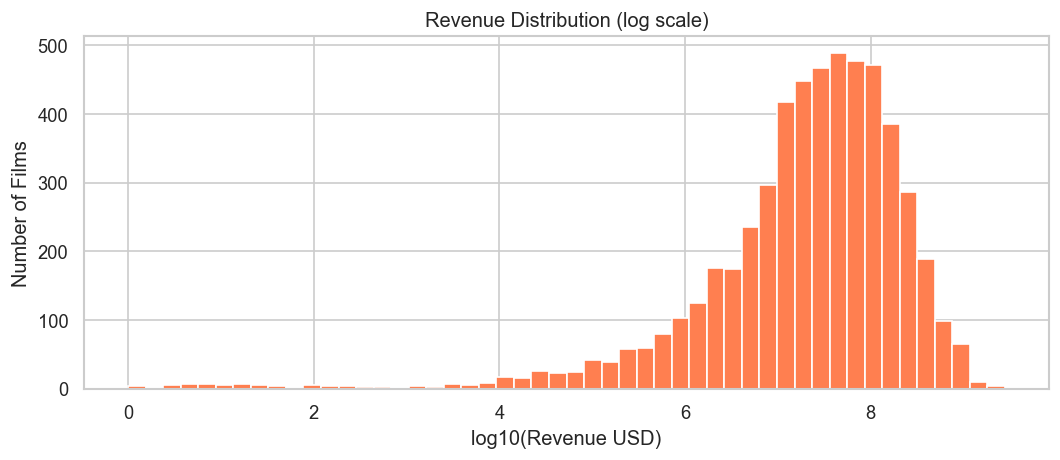

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.log10(df['revenue']), bins=50, color='coral', edgecolor='white')
ax.set_xlabel('log10(Revenue USD)')
ax.set_ylabel('Number of Films')
ax.set_title('Revenue Distribution (log scale)')
plt.tight_layout()
plt.show()

**Interpretation:** Revenue spans a wider range than budget (min $1 → max $2.79B). On log scale the center sits around log10(7.5) ≈ $30M. The heavier right tail compared to budget reflects blockbusters pulling revenue dramatically higher than the median.

## 3. Budget vs Revenue — Core Correlation

The core question: does a higher budget mean higher revenue?

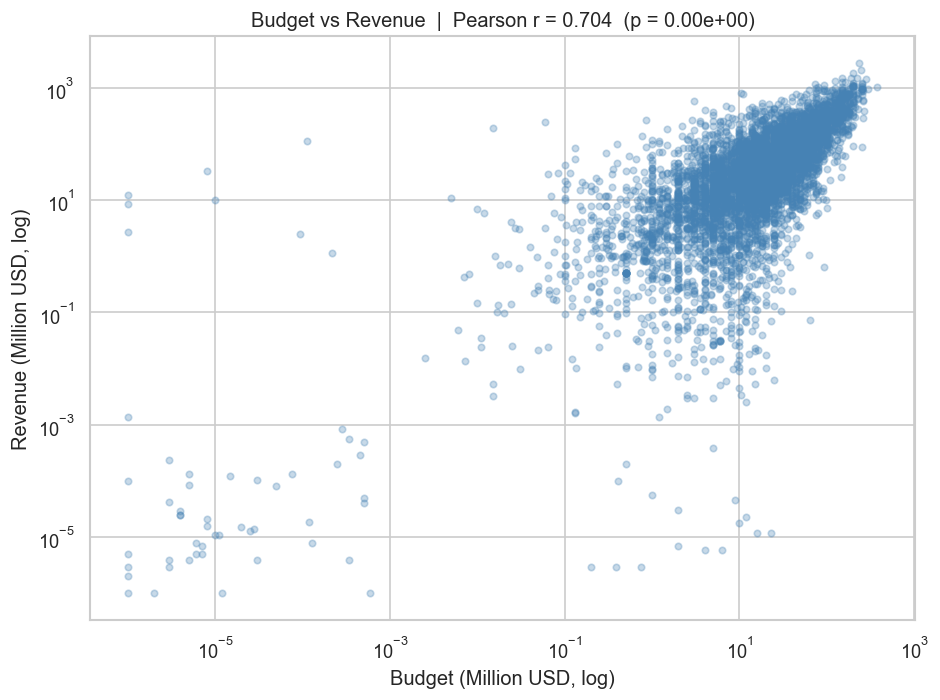

Pearson r (log scale): 0.704


In [5]:
subset = df[['budget', 'revenue']].dropna()
r, p = pearsonr(np.log10(subset['budget']), np.log10(subset['revenue']))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset['budget'] / 1e6, subset['revenue'] / 1e6,
           alpha=0.3, s=15, color='steelblue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Budget (Million USD, log)')
ax.set_ylabel('Revenue (Million USD, log)')
ax.set_title(f'Budget vs Revenue  |  Pearson r = {r:.3f}  (p = {p:.2e})')
plt.tight_layout()
plt.show()
print(f'Pearson r (log scale): {r:.3f}')

**Interpretation:** Pearson r = **0.704** (p ≈ 0) — strong positive correlation. On log-log scale r² ≈ 0.50, meaning budget explains approximately 50% of revenue variance. Direct answer to the core question: higher budget does mean higher revenue, but scatter is wide — the same Blockbuster budget can produce vastly different revenues. Budget is a necessary but not sufficient condition for box office success.

## 4. Budget vs IMDb Rating

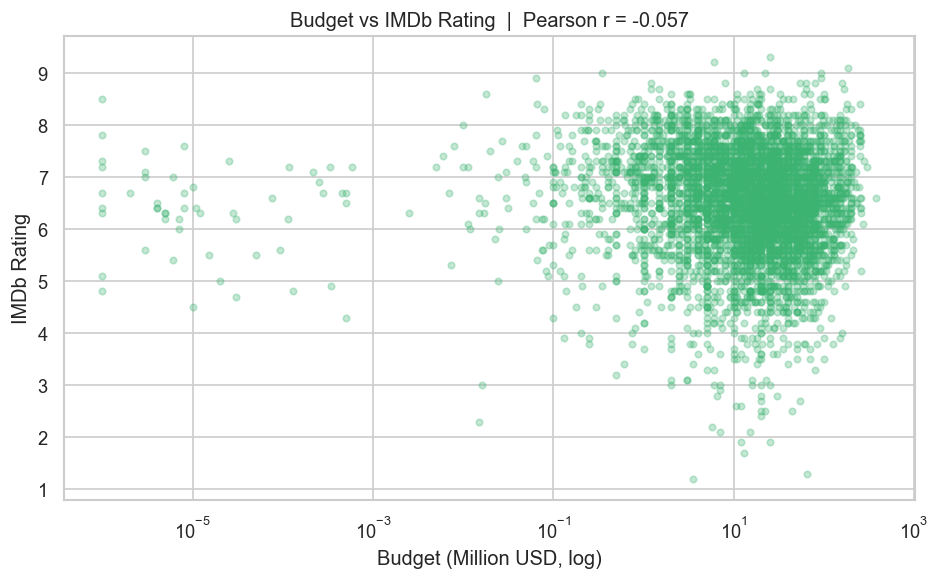

In [6]:
rating_col = 'imdb_rating' if 'imdb_rating' in df.columns else 'vote_average'
subset2 = df[['budget', rating_col]].dropna()
r2, p2 = pearsonr(np.log10(subset2['budget']), subset2[rating_col])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(subset2['budget'] / 1e6, subset2[rating_col],
           alpha=0.3, s=15, color='mediumseagreen')
ax.set_xscale('log')
ax.set_xlabel('Budget (Million USD, log)')
ax.set_ylabel('IMDb Rating')
ax.set_title(f'Budget vs IMDb Rating  |  Pearson r = {r2:.3f}')
plt.tight_layout()
plt.show()

**Interpretation:** Pearson r = **-0.057** — practically zero correlation. Budget explains less than 0.3% of IMDb score variance (r² < 0.003). Higher-budget films do not receive higher ratings; expensive films often land near the average. Quality cannot be bought.

## 5. Budget vs Tomatometer

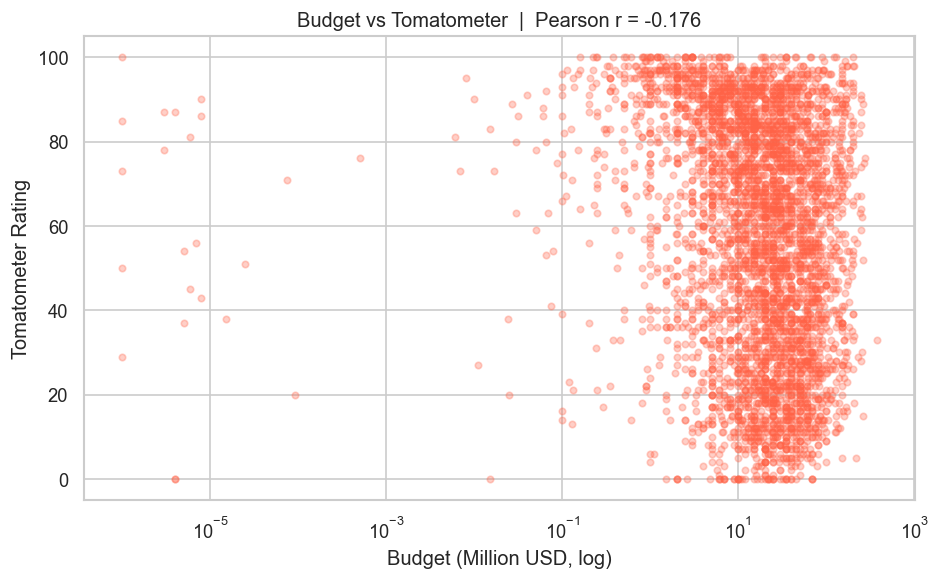

In [7]:
if 'tomatometer_rating' in df.columns:
    subset3 = df[['budget', 'tomatometer_rating']].dropna()
    r3, _ = pearsonr(np.log10(subset3['budget']), subset3['tomatometer_rating'])
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(subset3['budget'] / 1e6, subset3['tomatometer_rating'],
               alpha=0.3, s=15, color='tomato')
    ax.set_xscale('log')
    ax.set_xlabel('Budget (Million USD, log)')
    ax.set_ylabel('Tomatometer Rating')
    ax.set_title(f'Budget vs Tomatometer  |  Pearson r = {r3:.3f}')
    plt.tight_layout()
    plt.show()
else:
    print('tomatometer_rating column not found — RT join may have failed')

**Interpretation:** Pearson r = **-0.176** — low but statistically significant negative correlation (p ≈ 7×10⁻³²). Higher-budget films score slightly lower with critics. Likely reason: major studios avoid artistic risk in favor of commercial safety, whereas independent productions can offer more original content on smaller budgets.

## 6. Median ROI by Budget Tier

Which budget group delivers the highest return on investment?

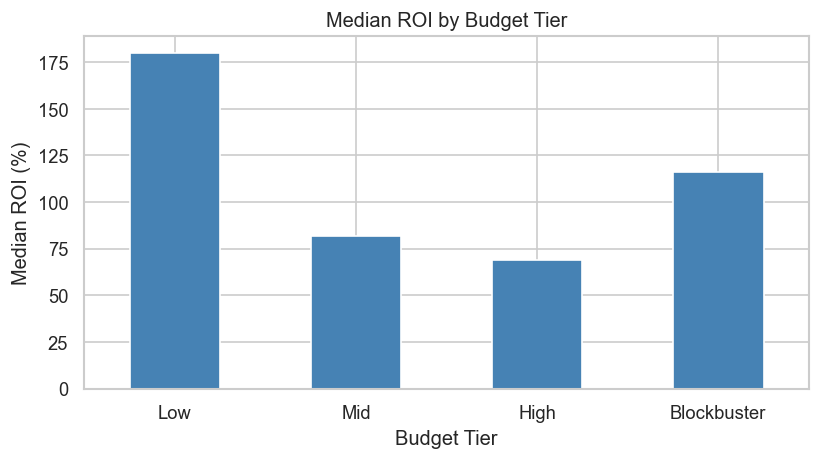

budget_tier
Low            180.000000
Mid             82.020936
High            69.038334
Blockbuster    116.341535
Name: roi, dtype: float64


In [8]:
tier_order = ['Low', 'Mid', 'High', 'Blockbuster']
roi_by_tier = (
    df.groupby('budget_tier', observed=True)['roi']
    .median()
    .reindex(tier_order)
)

fig, ax = plt.subplots(figsize=(7, 4))
roi_by_tier.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Median ROI (%)')
ax.set_title('Median ROI by Budget Tier')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print(roi_by_tier)

**Interpretation:** Median ROI — Low: **180%**, Mid: **82%**, High: **69%**, Blockbuster: **116%**. Low-budget films deliver the highest median return: large gains are achievable from small investments. Blockbuster surpassing Mid/High is notable — franchise/IP power provides reliable box office draw. The riskiest zone is Mid–High: large spend without blockbuster pull.

## 7. Average IMDb Rating by Budget Tier

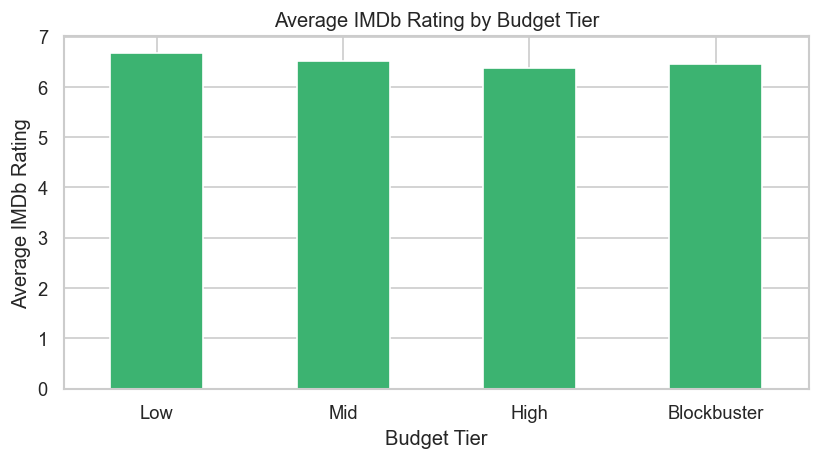

budget_tier
Low            6.674777
Mid            6.515147
High           6.378592
Blockbuster    6.458480
Name: imdb_rating, dtype: float64


In [9]:
rating_col = 'imdb_rating' if 'imdb_rating' in df.columns else 'vote_average'
rating_by_tier = (
    df.groupby('budget_tier', observed=True)[rating_col]
    .mean()
    .reindex(tier_order)
)

fig, ax = plt.subplots(figsize=(7, 4))
rating_by_tier.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Average IMDb Rating')
ax.set_title('Average IMDb Rating by Budget Tier')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print(rating_by_tier)

**Interpretation:** Average IMDb scores — Low: **6.67**, Mid: **6.52**, High: **6.38**, Blockbuster: **6.46**. The gap is small (~0.3 points) but consistent: rating drops slightly as budget increases. Low-budget films scoring highest may partly reflect selection bias (only notable independent films enter the dataset), but the pattern confirms budget is not a quality indicator.

## 8. Top 20 — Highest ROI

Are these low-budget or high-budget films?

In [10]:
top_roi = (
    df[['title', 'budget', 'revenue', 'roi', 'budget_tier', 'primary_genre']]
    .dropna(subset=['roi'])
    .sort_values('roi', ascending=False)
    .head(20)
)
top_roi['budget_M']  = (top_roi['budget'] / 1e6).round(1)
top_roi['revenue_M'] = (top_roi['revenue'] / 1e6).round(1)
top_roi['roi']       = top_roi['roi'].round(0).astype(int)
top_roi[['title', 'budget_M', 'revenue_M', 'roi', 'budget_tier', 'primary_genre']]

,title,budget_M,revenue_M,roi,budget_tier,primary_genre
1460,Less Than Zero,0.0,12.4,1239638200,Low,Drama
1240,Modern Times,0.0,8.5,849999900,Low,Drama
3463,Welcome to Dongmakgol,0.0,33.6,419747562,Low,War
4374,Aquí Entre Nos,0.0,2.8,275558300,Low,Comedy
883,"The Karate Kid, Part II",0.0,115.1,101861828,Low,Adventure
4630,Nurse 3-D,0.0,10.0,99999900,Low,Horror
3741,From Prada to Nada,0.0,2.5,2688072,Low,Comedy
3433,Paranormal Activity,0.0,193.4,1288939,Low,Horror
2411,Tarnation,0.0,1.2,532934,Low,Documentary
990,The Blair Witch Project,0.1,248.0,413233,Low,Horror


## 9. Top 20 — Biggest Flops

Blockbuster-budget films with the lowest ROI.

In [11]:
flops = (
    df[df['budget_tier'] == 'Blockbuster'][['title', 'budget', 'revenue', 'roi', 'primary_genre']]
    .dropna(subset=['roi'])
    .sort_values('roi')
    .head(20)
)
flops['budget_M']  = (flops['budget'] / 1e6).round(1)
flops['revenue_M'] = (flops['revenue'] / 1e6).round(1)
flops['roi']       = flops['roi'].round(0).astype(int)
flops[['title', 'budget_M', 'revenue_M', 'roi', 'primary_genre']]

,title,budget_M,revenue_M,roi,primary_genre
4620,Foodfight!,65.0,0.1,-100,Animation
713,Metropolis,92.6,0.7,-99,Drama
724,Lolita,62.0,1.1,-98,Drama
351,Shadow Conspiracy,45.0,2.2,-95,Action
4714,Child 44,50.0,3.3,-93,Crime
1834,The Adventures of Pluto Nash,100.0,7.1,-93,Action
1470,Monkeybone,75.0,5.4,-93,Adventure
2496,A Sound of Thunder,80.0,6.0,-93,Thriller
3616,Mr. Nobody,47.0,3.5,-92,Science Fiction
1754,Heaven's Gate,44.0,3.5,-92,Action


## 10. Median Budget by Genre

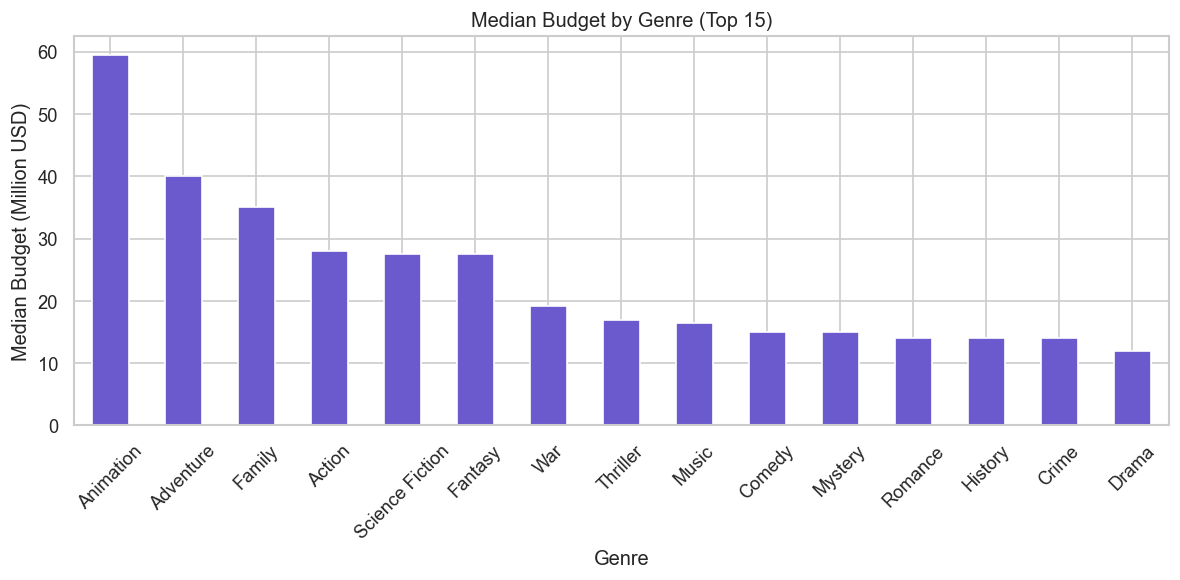

In [12]:
genre_budget = (
    df.groupby('primary_genre')['budget']
    .median()
    .sort_values(ascending=False)
    .head(15)
) / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
genre_budget.plot(kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_xlabel('Genre')
ax.set_ylabel('Median Budget (Million USD)')
ax.set_title('Median Budget by Genre (Top 15)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** Animation (**$59.5M**) and Adventure (**$40M**) have the highest median budgets — driven by CGI and large production costs. Family and Action follow in the $28–35M range. Horror and Documentary do not appear in this top-15 because they typically shoot on very low budgets, which explains why they deliver the highest ROI.

## 11. Budget and Revenue Trend by Decade

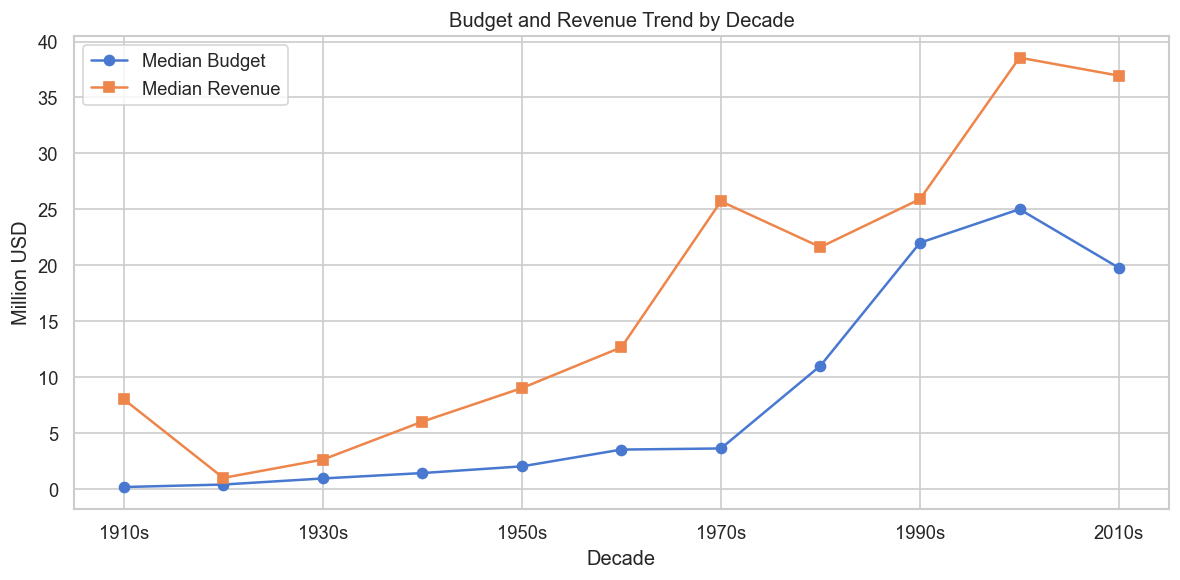

,budget,revenue
decade,,
1910s,0.1500,8.000000
1920s,0.3730,0.966878
1930s,0.9165,2.605000
1940s,1.4000,6.000000
1950s,2.0000,9.000000
1960s,3.5000,12.649834
1970s,3.6000,25.707329
1980s,11.0000,21.611388
1990s,22.0000,25.900880


In [13]:
decade_stats = (
    df.groupby('decade')[['budget', 'revenue']]
    .median()
    .dropna()
    .sort_index()
) / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
decade_stats['budget'].plot(ax=ax, marker='o', label='Median Budget')
decade_stats['revenue'].plot(ax=ax, marker='s', label='Median Revenue')
ax.set_xlabel('Decade')
ax.set_ylabel('Million USD')
ax.set_title('Budget and Revenue Trend by Decade')
ax.legend()
plt.tight_layout()
plt.show()
decade_stats

**Interpretation:** Both budget and revenue grew consistently across the century. 1910s: budget $0.2M → revenue $8M; 2000s peak: budget $25M → revenue $38.6M. In the 2010s budget dipped to $19.8M while revenue held at $36.9M — the widening gap may reflect falling unit production costs in the streaming era or studios optimizing spend. Revenue exceeded budget in every decade: the industry is consistently profitable on a median basis.